# 0. Imports

In [1]:
## Imports

import os
import math
from datetime import datetime
from itertools import product as itertools_product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
from sklearn.model_selection import KFold
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import normalize as sklearn_normalize
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
import jax
from jax import numpy as jnp
#import jax.scipy.linalg


from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split

In [2]:
def plot_regression_dataset(X, y, y_pred=None, title="Linear Regression Dataset"):
    """
    Plot the regression dataset and optionally the predictions

    Parameters:
    -----------
    X : numpy array
        Input features
    y : numpy array
        True target values
    y_pred : numpy array, optional
        Predicted target values
    title : str
        Plot title
    """
    plt.figure(figsize=(10, 6))

    # Plot actual data points
    plt.scatter(X, y, alpha=0.6, label='Actual data', color='blue')

    # Plot predictions if provided
    if y_pred is not None:
        # Sort by X for proper line plotting
        sorted_indices = np.argsort(X.flatten())
        plt.plot(X[sorted_indices], y_pred[sorted_indices],
                color='red', linewidth=2, label='Predictions')

    plt.xlabel('X')
    plt.ylabel('y')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# 1. Dataset

In [3]:
def plot_regression_dataset(X, y, y_pred=None, title="Linear Regression Dataset", y_lim=None):
    """
    Plot the regression dataset and optionally the predictions

    Parameters:
    -----------
    X : numpy array
        Input features
    y : numpy array
        True target values
    y_pred : numpy array, optional
        Predicted target values
    title : str
        Plot title
    """
    plt.figure(figsize=(10, 6))

    # Plot actual data points
    plt.scatter(X, y, alpha=0.6, label='Actual data', color='blue')

    if y_pred is not None:
      plt.plot(X, y_pred,
            color='red', linewidth=2, label='Predictions')

    plt.xlabel('X')
    plt.ylabel('y')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    if y_lim is not None:
        plt.ylim(y_lim)
    plt.show()

In [4]:
def generate_dataset(x_min=-1, x_max=1, padding_size=1,dataset_size=300, repeat_input=False,func=None):

  X = np.linspace(x_min, x_max, dataset_size).reshape(-1, 1)
  y_exact = func(X)


  # Create a new column of zeros with the same number of rows
  new_column = 0.9*np.ones((X.shape[0], padding_size))

  # Add the new column to the right of the matrix
  # Use axis=1 for column-wise concatenation
  X_final = np.concatenate((X, new_column), axis=1)

  if repeat_input:
    X_final = np.concatenate((X_final,np.repeat(X, repeat_input,axis=1)), axis=1)

  print(X_final.shape[1],)

  import math
  if math.log(X_final.shape[1],2) != int(math.log(X_final.shape[1],2)):
    print("Final dataset is not power of 2")

  return X, X_final, y_exact

In [5]:
def evaluate_model(best_params, X, X_final, y_exact):

  def evaluate(params, data):
    y_pred = jax.vmap(regressor, in_axes=(0,None))(data, params)
    return y_pred

  y_predictions=evaluate(best_params,X_final)
  from sklearn.metrics import r2_score
  r2 = round(float(r2_score(y_exact, y_predictions)),3)
  print("R^2 Score:", r2)
  plot_regression_dataset(X, y_exact, y_predictions,title="Real data vs. Prediction values")
  return r2

In [6]:
def evaluate_plot_model(best_params, X, X_final, y_exact,plot=False):

  def evaluate(params, data):
    y_pred = [regressor(x, params) for x in data]
    return y_pred

  y_predictions=evaluate(best_params,X_final)
  from sklearn.metrics import r2_score
  r2 = round(float(r2_score(y_exact, y_predictions)),3)
  print("R^2 Score:", r2)
  if plot:
    plot_regression_dataset(X, y_exact, y_predictions,title="Real data vs. Prediction values")
  return r2

# 3. IQC Functions

Core IQC helper functions (sigma_Q, sigma_E, U, p, negativity, entropy)

## Normalize

In [7]:
def normalize(x):
    return x / (np.linalg.norm(x) + 1e-16)

## Get_p (|psi><psi|)

In [8]:
def get_p(psi):
    """
    |psi><psi| density matrix.
    """
    psi = np.matrix(psi)
    return psi * psi.getH()

## Get Weighted SigmaQ

In [9]:
def get_weighted_sigmaQ_jnp(param, iqcpq=False):
    """
    Build sigma_Q.

    - If iqcpq=False: linear combination of Pauli matrices + identity (Eq. 16).
    - If iqcpq=True: builds an n-level Hermitian matrix with fixed diagonal/off-diagonal.
    """
    if iqcpq:
        n = len(param)
        diagonal = jnp.full(n, 1, dtype=complex)
        diagonal[-1] = -jnp.sum(diagonal[:-1])

        off_diagonal = jnp.full((n, n), 1 + 1j, dtype=complex)
        matrix = jnp.zeros((n, n), dtype=complex)
        jnp.fill_diagonal(matrix, diagonal)
        for i in range(n):
            for j in range(i + 1, n):
                matrix[i, j] = off_diagonal[i, j]
                matrix[j, i] = jnp.conj(off_diagonal[i, j])
        return matrix

    sigmaX = jnp.array([[0, 1], [1, 0]], dtype=complex)
    sigmaY = jnp.array([[0, -1j], [1j, 0]], dtype=complex)
    sigmaZ = jnp.array([[1, 0], [0, -1]], dtype=complex)
    identity = jnp.array([[1, 0], [0, 1]], dtype=complex)

    sigmaQ = (
        param[0] * sigmaX
        + param[1] * sigmaY
        + param[2] * sigmaZ
        + param[3] * identity
    )
    sigmaq_trace = jnp.trace(sigmaQ)
    #if sigmaq_trace > 0:
    #    return jnp.array(sigmaQ) / sigmaq_trace
    return jnp.array(sigmaQ) / (sigmaq_trace+0.000000000000000000001)
    #return jnp.array(sigmaQ)

def get_weighted_sigmaQ(param, iqcpq=False):
    """
    Build sigma_Q.

    - If iqcpq=False: linear combination of Pauli matrices + identity (Eq. 16).
    - If iqcpq=True: builds an n-level Hermitian matrix with fixed diagonal/off-diagonal.
    """
    if iqcpq:
        n = len(param)
        diagonal = np.full(n, 1, dtype=complex)
        diagonal[-1] = -np.sum(diagonal[:-1])

        off_diagonal = np.full((n, n), 1 + 1j, dtype=complex)
        matrix = np.zeros((n, n), dtype=complex)
        np.fill_diagonal(matrix, diagonal)
        for i in range(n):
            for j in range(i + 1, n):
                matrix[i, j] = off_diagonal[i, j]
                matrix[j, i] = np.conj(off_diagonal[i, j])
        return matrix

    sigmaX = np.array([[0, 1], [1, 0]], dtype=complex)
    sigmaY = np.array([[0, -1j], [1j, 0]], dtype=complex)
    sigmaZ = np.array([[1, 0], [0, -1]], dtype=complex)
    identity = np.array([[1, 0], [0, 1]], dtype=complex)

    sigmaQ = (
        param[0] * sigmaX
        + param[1] * sigmaY
        + param[2] * sigmaZ
        + param[3] * identity
    )
    sigmaq_trace = np.trace(sigmaQ)
    if sigmaq_trace > 0:
        return np.array(sigmaQ) / sigmaq_trace
    return np.array(sigmaQ)

## Get SigmaQ from Polar Coord

In [10]:
def get_sigmaQ_from_polar_coord(param):
    """
    Polar-coordinates version of sigma_Q, normalized to trace 1.
    """
    r, theta, phi = param

    rx = r * np.sin(theta) * np.cos(phi)
    ry = r * np.sin(theta) * np.sin(phi)
    rz = r * np.cos(theta)

    sigmaX = np.array([[0, 1], [1, 0]], dtype=complex)
    sigmaY = np.array([[0, -1j], [1j, 0]], dtype=complex)
    sigmaZ = np.array([[1, 0], [0, -1]], dtype=complex)
    identity = np.array([[1, 0], [0, 1]], dtype=complex)

    return (identity + rx * sigmaX + ry * sigmaY + rz * sigmaZ) / 2.0

## Get Sigma E

In [11]:
def get_sigmaE(vector_x, vector_w, dic_classifier_params, ndse=False):
    """
    Environment operator sigma_E (Eq. 17), JAX-compatible.
    """
    load_inputvector_env_state = dic_classifier_params.get(
        "load_inputvector_env_state", False
    )

    vx = jnp.atleast_1d(vector_x).flatten()
    vw = jnp.atleast_1d(vector_w).flatten()

    if load_inputvector_env_state:
        return jnp.diag(vx)
    # default: element-wise product on diagonal
    return jnp.diag(vx * vw)

## Get U

In [12]:
import scipy
def get_U_operator_jax(sigmaQ, sigmaE):
    """
    U = exp(+i * (sigma_Q ⊗ sigma_E))  (Eq. 15/22 from the paper).
    Derived from H_int = -ℏg σ_Q⊗σ_E and U(t) = exp(-iH_int t/ℏ).
    """
    H = jnp.kron(sigmaQ, sigmaE)
    U = jax.scipy.linalg.expm(1j * H)
    return U

def get_U_operator(sigmaQ, sigmaE):
    """
    U = exp(+i * (sigma_Q ⊗ sigma_E))  (Eq. 15/22 from the paper).
    Derived from H_int = -ℏg σ_Q⊗σ_E and U(t) = exp(-iH_int t/ℏ).
    """
    H = np.kron(sigmaQ, sigmaE)
    U = scipy.linalg.expm(1j * H)
    return U

# 4. IQC Regressor main method

In [13]:
def iqc_regressor(
    vector_x,
    vector_ws,
    normalize_x=False,
    normalize_w=False,
    dic_classifier_params=None,
    N_qubits=None,
    N_qubits_tgt=None,
    load_inputvector_env_state=False #Brito et al. Model (amplitude encoding of information)
):
    """
    Core IQC-based regressor (inference path):
    - Builds sigma_Q, sigma_E
    - Evolves ρ_cog ⊗ ρ_env via U
    - Takes partial trace over environment
    - Returns expectation value of Pauli-Z as regressed output.
    """

    bias = vector_ws[0]
    c1 = 1#vector_ws[1]
    c2 = 1#vector_ws[2]
    c3 = 1#vector_ws[3]
    c4 = 1#vector_ws[4]
    vector_ws = vector_ws[1:]

    if dic_classifier_params is None:
        dic_classifier_params = {}

    N = len(vector_x)

    sigma_q_params = dic_classifier_params.get("sigma_q_params", [c1,c2,c3,c4])
    use_polar_coordinates_on_sigma_q = dic_classifier_params.get(
        "use_polar_coordinates_on_sigma_q", False
    )

    if normalize_x:
        vector_x = normalize(vector_x)
    if dic_classifier_params.get("use_exponential_on_input", False):
        vector_x = np.exp(vector_x)

    if use_polar_coordinates_on_sigma_q:
        sigmaQ = get_sigmaQ_from_polar_coord(sigma_q_params)
    else:
        sigmaQ = get_weighted_sigmaQ_jnp(sigma_q_params)

    sigmaQ = jnp.array(sigmaQ, dtype=jnp.complex64)

    vector_x = jnp.array(vector_x, dtype=jnp.float32)

    p_env = jnp.ones((N, 1)) / jnp.sqrt(N)
    p_env = p_env @ p_env.T

    p_cog = jnp.ones((2, 1)) / jnp.sqrt(2)
    p_cog = p_cog @ p_cog.T

    ##vector_ws_jnp = jnp.array(vector_ws, dtype=jnp.float32) #[jnp.array(w, dtype=jnp.float32) for w in vector_ws]
    vector_ws = jnp.array(vector_ws, dtype=jnp.float32) #[jnp.array(w, dtype=jnp.float32) for w in vector_ws]

    p_cog_new = p_cog
    U_operators = []
    p_out = None


    if normalize_w:
        vector_w = vector_w / (jnp.linalg.norm(vector_w) + 1e-16)

    # Equivalent to Eq #15
    if load_inputvector_env_state:

        # We can either keep only weights (in case we have only one environment)
        #sigmaE = jnp.diag(jnp.array(vector_w, dtype=jnp.float32))
        sigmaE = jnp.diag(vector_ws)
    else:
        # Or keep both as the original ICQ article
        #sigmaE = get_sigmaE(vector_x, vector_w, dic_classifier_params)
        sigmaE = jnp.diag(jnp.multiply(vector_x , vector_ws))

    # Eq #19 applied on a Quantum state equivalent of Hadamard(|00...0>) = 1/sqrt(N) * (|00...0> + ... + |11...1>)
    if load_inputvector_env_state:
        # We can either have Hadamard applied to each instance attribute...
        vector_x_norm = (jnp.linalg.norm(vector_x) + 1e-16)

        # env = x1/norm(x) |0> + x2/norm(x) |1> .... + xn/norm(x) |n>
        p_env = jnp.array(vector_x).reshape((N, 1)) / vector_x_norm
        p_env = p_env @ p_env.T


    #sigmaE = jnp.diag(vector_x * vector_w)
    U_operator = get_U_operator_jax(sigmaQ, sigmaE)
    U_operators.append(U_operator)

    p_cog_env = jnp.kron(p_cog_new, p_env)
    p_out = U_operator @ p_cog_env @ jnp.conj(U_operator).T
    p_cog_new = jnp.trace(p_out.reshape([2, N, 2, N]), axis1=1, axis2=3)

    p_cog_new_00 = jnp.real(p_cog_new[0, 0])
    p_cog_new_11 = jnp.real(p_cog_new[1, 1])

    pauli_z = jnp.array([[1, 0], [0, -1]], dtype=jnp.complex64)
    expectation = jnp.real(jnp.trace(p_cog_new @ pauli_z))

    output_dict = {
        "U_operators": U_operators,
        "p_00": p_cog_new_00,
        "p_11": p_cog_new_11,
    }

    #return expectation, p_cog_new_11, output_dict
    return expectation + bias


iqc_regressor_chinese = lambda x, w: iqc_regressor(x,w)
iqc_regressor_brito = lambda x,w:iqc_regressor(x,w,load_inputvector_env_state=True)

In [14]:
def iqc_regressor_numpy(
    vector_x,
    vector_ws,
    normalize_x=False,
    normalize_w=False,
    dic_classifier_params=None,
    N_qubits=None,
    N_qubits_tgt=None,
    load_inputvector_env_state=False #Brito et al. Model (amplitude encoding of information)
):


    """
    Core IQC-based regressor (inference path):
    - Builds sigma_Q, sigma_E
    - Evolves ρ_cog ⊗ ρ_env via U
    - Takes partial trace over environment
    - Returns expectation value of Pauli-Z as regressed output.
    """

    bias = vector_ws[0]
    c1 = 1#vector_ws[1]
    c2 = 1#vector_ws[2]
    c3 = 1#vector_ws[3]
    c4 = 1#vector_ws[4]
    vector_ws = vector_ws[1:]

    if dic_classifier_params is None:
        dic_classifier_params = {}

    N = len(vector_x)

    sigma_q_params = dic_classifier_params.get("sigma_q_params", [c1,c2,c3,c4])
    use_polar_coordinates_on_sigma_q = dic_classifier_params.get(
        "use_polar_coordinates_on_sigma_q", False
    )

    if normalize_x:
        vector_x = normalize(vector_x)
    if dic_classifier_params.get("use_exponential_on_input", False):
        vector_x = np.exp(vector_x)

    if use_polar_coordinates_on_sigma_q:
        sigmaQ = get_sigmaQ_from_polar_coord(sigma_q_params)
    else:
        sigmaQ = get_weighted_sigmaQ(sigma_q_params)

    sigmaQ = np.array(sigmaQ, dtype=np.complex64)

    ##vector_x = jnp.array(vector_x, dtype=jnp.float32)

    p_env = np.ones((N, 1)) / np.sqrt(N)
    p_env = p_env @ p_env.T

    p_cog = np.ones((2, 1)) / np.sqrt(2)
    p_cog = p_cog @ p_cog.T

    ##vector_ws_jnp = jnp.array(vector_ws, dtype=jnp.float32) #[jnp.array(w, dtype=jnp.float32) for w in vector_ws]

    p_cog_new = p_cog
    U_operators = []
    p_out = None


    if normalize_w:
        vector_w = vector_w / (np.linalg.norm(vector_w) + 1e-16)

    # Equivalent to Eq #15
    if load_inputvector_env_state:

        # We can either keep only weights (in case we have only one environment)
        #sigmaE = jnp.diag(jnp.array(vector_w, dtype=jnp.float32))
        sigmaE = np.diag(vector_ws)
    else:
        # Or keep both as the original ICQ article
        #sigmaE = get_sigmaE(vector_x, vector_w, dic_classifier_params)
        sigmaE = np.diag(np.multiply(vector_x , vector_ws))

    # Eq #19 applied on a Quantum state equivalent of Hadamard(|00...0>) = 1/sqrt(N) * (|00...0> + ... + |11...1>)
    if load_inputvector_env_state:
        # We can either have Hadamard applied to each instance attribute...
        vector_x_norm = (np.linalg.norm(vector_x) + 1e-16)

        # env = x1/norm(x) |0> + x2/norm(x) |1> .... + xn/norm(x) |n>
        p_env = np.array(vector_x).reshape((N, 1)) / vector_x_norm
        p_env = p_env @ p_env.T


    #sigmaE = jnp.diag(vector_x * vector_w)
    U_operator = get_U_operator(sigmaQ, sigmaE)
    U_operators.append(U_operator)

    p_cog_env = np.kron(p_cog_new, p_env)
    p_out = U_operator @ p_cog_env @ np.conj(U_operator).T
    p_cog_new = np.trace(p_out.reshape([2, N, 2, N]), axis1=1, axis2=3)

    p_cog_new_00 = np.real(p_cog_new[0, 0])
    p_cog_new_11 = np.real(p_cog_new[1, 1])

    pauli_z = np.array([[1, 0], [0, -1]], dtype=np.complex64)
    expectation = np.real(np.trace(p_cog_new @ pauli_z))

    output_dict = {
        "U_operators": U_operators,
        "p_00": p_cog_new_00,
        "p_11": p_cog_new_11,
    }

    #return expectation, p_cog_new_11, output_dict
    return expectation + bias

iqc_regressor_chinese_numpy = lambda x, w: iqc_regressor_numpy(x,w)
iqc_regressor_brito_numpy = lambda x,w:iqc_regressor_numpy(x,w,load_inputvector_env_state=True)

#5. Training Functions

##5.1 - Functions

In [15]:
def func1(X):
  return 0.5*X

def func2(X):
  return 0.5*X**2 - 0.5

def func3(X):
  return 1/10*(0.4*X*X*X + 0.5*X*X + 0.4*X )

def func4(X):
  return 0.2*jnp.sin(2*X)

def func5(X):
  return 0.5*jnp.sin(4*X)

def func6(X):
  return 0.5*jnp.sin(2*X) + 0.8*jnp.cos(4*X)

def func7(X):
  return 0.9*jnp.sin(2*X) + 0.1*jnp.cos(X)

def g(x,k_lim=2):
  sum=0
  for k in range(-k_lim,k_lim+1):
    if k==0:
      ck = 0.1
    else:
      ck = 0.05+1j*0.05
    sum+= ck * np.exp(1j*k*x)
  return sum.real

2


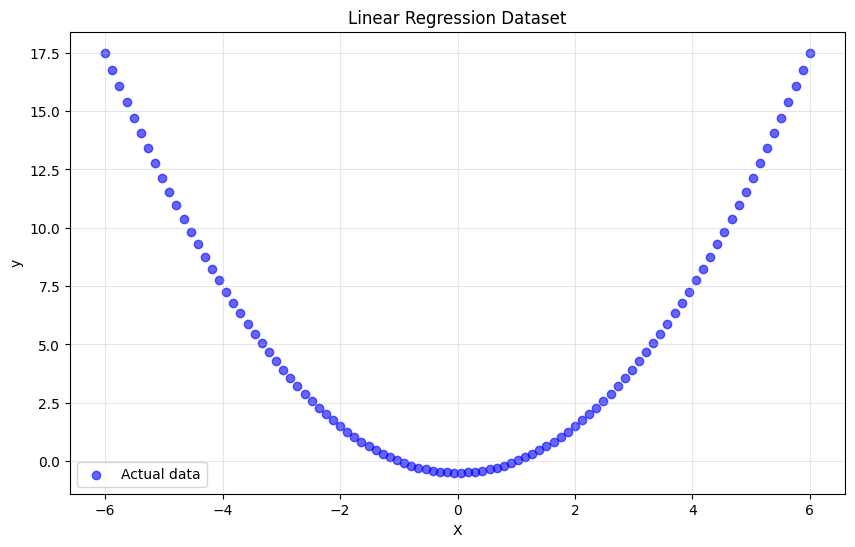

In [16]:
X, X_final, y_exact = generate_dataset(x_min=-6, x_max=6, padding_size=1,repeat_input=False,dataset_size=100, func=func2)
plot_regression_dataset(X, y_exact)

##5.2 - Optimizer

In [17]:
import jax
from jax import numpy as jnp
import optax
import jax
from jax import numpy as jnp
import optax

regressor = iqc_regressor_chinese #iqc_regressor_brito#

@jax.jit
def mse(vector_ws,vector_x,targets):
    # We compute the mean square error between the target function and the quantum circuit to quantify the quality of our estimator
    return (regressor(vector_x,vector_ws)-jnp.array(targets))**2
@jax.jit
def loss_fn(params, x,targets):
    # We define the loss function to feed our optimizer
    mse_pred = jax.vmap(mse,in_axes=(None, 0,0))(params,x,targets)
    loss = jnp.mean(mse_pred)
    return loss

def calculate_r2_manual(y_true, y_pred):
    # Convert to numpy arrays for easier calculations
    #y_true = np.array(y_true)
    #y_pred = np.array(y_pred)

    # Calculate the mean of the true values
    y_true_mean = jnp.mean(y_true)

    # Calculate Sum of Squared Residuals (SS_res)
    ss_res = jnp.sum((y_true - y_pred)**2)

    # Calculate Total Sum of Squares (SS_tot)
    ss_tot = jnp.sum((y_true - y_true_mean)**2)

    # Handle the case where SS_tot is zero (e.g., all y_true values are the same)
    #if ss_tot == 0:
    #    return 1.0 if ss_res == 0 else 0.0 # Perfect prediction or no variance to explain

    # Calculate R-squared
    r2 = 1 - (ss_res / ss_tot)
    return r2

def loss_fn_r2(params, x,targets):
  y_pred = jax.vmap(regressor, in_axes=(0,None))(x, params)

  return -calculate_r2_manual(targets, y_pred)




def training_model(X=None, X_final=None, y_exact=None, max_steps=1000):
  opt = optax.adamax(learning_rate=0.01)

  @jax.jit
  def update_step_jit(i, args):
      # We loop over this function to optimize the trainable parameters
      params, opt_state, data, targets, print_training = args
      loss_val, grads = jax.value_and_grad(loss_fn)(params, data, targets)
      updates, opt_state = opt.update(grads, opt_state)
      params = optax.apply_updates(params, updates)

      def print_fn():
          jax.debug.print("Step: {i}  Loss: {loss_val}", i=i, loss_val=loss_val)
      # if print_training=True, print the loss every 50 steps
      jax.lax.cond((jnp.mod(i, 50) == 0 ) & print_training, print_fn, lambda: None)
      return (params, opt_state, data, targets, print_training)

  @jax.jit
  def optimization_jit(params, data, targets, print_training=False):
      opt_state = opt.init(params)
      args = (params, opt_state, jnp.asarray(data), targets, print_training)
      # We loop over update_step_jit max_steps iterations to optimize the parameters
      (params, opt_state, _, _, _) = jax.lax.fori_loop(0, max_steps+1, update_step_jit, args)
      return params

  n_input_features_final=X_final.shape[1]

  #weights = jnp.ones(n_input_features_final)
  #bias = jnp.array(0.)
  #params = {"weights": weights, "bias": bias}

  key = jax.random.key(10)
  print("qtde params", n_input_features_final)
  params_shape = (n_input_features_final+1,) #FOI RETIRADO O +4, pois o sigmaQ está 1,1,1,1
  params = np.random.random(size=params_shape)#jax.random.uniform(key, shape=params_shape,minval=-50, maxval=50) #np.random.random(size=params_shape)
  best_params=optimization_jit(params, X_final, jnp.array(y_exact), print_training=True)

  return best_params



##5.2 - PSO

In [18]:
%pip install pyswarms


Note: you may need to restart the kernel to use updated packages.


In [19]:

import numpy
import pyswarms as ps

regressor = iqc_regressor_chinese_numpy #iqc_regressor_brito#

def fitness_func(solutions, X_final):
  results = []
  #y_pred = jax.vmap(regressor, in_axes=(0,None))(X, solution)
  for solution in solutions:
    #y_pred = [regressor(X,solution) for X in X_final]

    #def evaluate(params, data):
    y_pred = jax.vmap(regressor, in_axes=(0,None))(X_final, jnp.array(solution))
    #return y_pred
  
    #fitness = np.mean((np.array(y_exact)-np.array(y_pred))**2)#-r2_score(y_exact, y_pred)
    fitness = -r2_score(y_exact, y_pred)
    results.append(fitness)
  return results


def training_model_PSO(X=None, X_final=None, y_exact=None, max_steps=1000, n_particles=10, options_optimizer=None,verbose=False):

  n_input_features_final=X_final.shape[1]+1 #FOI RETIRADO o +4 porque esse modelo
  print("dim+1: ", n_input_features_final) #+1 because of BIAS value

  # Set-up hyperparameters
  # c1: cognitive parameter, c2: social parameter, w: inertia weight
  if options_optimizer is None:
    options_global_best = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
    #options_local_best = {'c1': 0.5, 'c2': 0.3, 'w': 0.9, 'k': 3, 'p': 2}

    options_optimizer = options_global_best


  # Call instance of GlobalBestPSO optimizer
  optimizer = ps.single.GlobalBestPSO(n_particles=n_particles, dimensions=n_input_features_final, options=options_optimizer)
  #optimizer = ps.single.LocalBestPSO(n_particles=n_particles, dimensions=n_input_features_final, options=options_local_best)

  # Perform optimization
  # The 'sphere' function is a built-in example objective function
  for ITER in range(max_steps):
    best_cost, best_pos = optimizer.optimize(lambda solutions: fitness_func(solutions, X_final), iters=1,verbose=verbose)
    #print("best cost", best_cost)
    if best_cost <= -0.995:
      print("finalizado na iteracao", ITER)
      break

  #best_cost, best_pos = optimizer.optimize(lambda solutions: fitness_func(solutions, X_final), iters=max_steps,verbose=True)

  print(f"Best cost: {best_cost}")
  print(f"Best position (x, y): {best_pos}")

  return best_pos, best_cost


##5.3 - Exemplos

In [20]:

regressor = iqc_regressor_chinese#iqc_regressor_brito#

X, X_final, y_exact = generate_dataset(x_min=-0.5, x_max=0.5, padding_size=0,repeat_input=1,dataset_size=100, func=func4)

best_pos, best_r2 = training_model_PSO(X, X_final, y_exact, max_steps=100,n_particles=10, verbose=False)

evaluate_plot_model(best_pos, X,X_final, y_exact)

INFO:2026-03-23 18:29:10,907:jax._src.xla_bridge:752: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2026-03-23 18:29:10,907 - jax._src.xla_bridge - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


2
dim+1:  3
Best cost: -0.9822295904159546
Best position (x, y): [-0.01514607  0.86006283 -0.10647369]
R^2 Score: 0.982


0.982

2
qtde params 2
Step: 0  Loss: 0.9174507856369019
Step: 50  Loss: 0.28078168630599976
Step: 100  Loss: 0.07830505818128586
Step: 150  Loss: 0.020419282838702202
Step: 200  Loss: 0.004972877912223339
Step: 250  Loss: 0.0011446719290688634
Step: 300  Loss: 0.0002696187002584338
Step: 350  Loss: 8.664066990604624e-05
Step: 400  Loss: 5.1947881729574874e-05
Step: 450  Loss: 4.60371193184983e-05
Step: 500  Loss: 4.513844760367647e-05
Step: 550  Loss: 4.501490911934525e-05
Step: 600  Loss: 4.4996588258072734e-05
Step: 650  Loss: 4.499080387176946e-05
Step: 700  Loss: 4.498566340771504e-05
Step: 750  Loss: 4.498095950111747e-05
Step: 800  Loss: 4.497585541685112e-05
Step: 850  Loss: 4.49704093625769e-05
Step: 900  Loss: 4.496488691074774e-05
Step: 950  Loss: 4.4959124352317303e-05
Step: 1000  Loss: 4.495311441132799e-05
Step: 1050  Loss: 4.4947089918423444e-05
Step: 1100  Loss: 4.4940858060726896e-05
Step: 1150  Loss: 4.493412416195497e-05
Step: 1200  Loss: 4.4927648559678346e-05
Step: 1250  

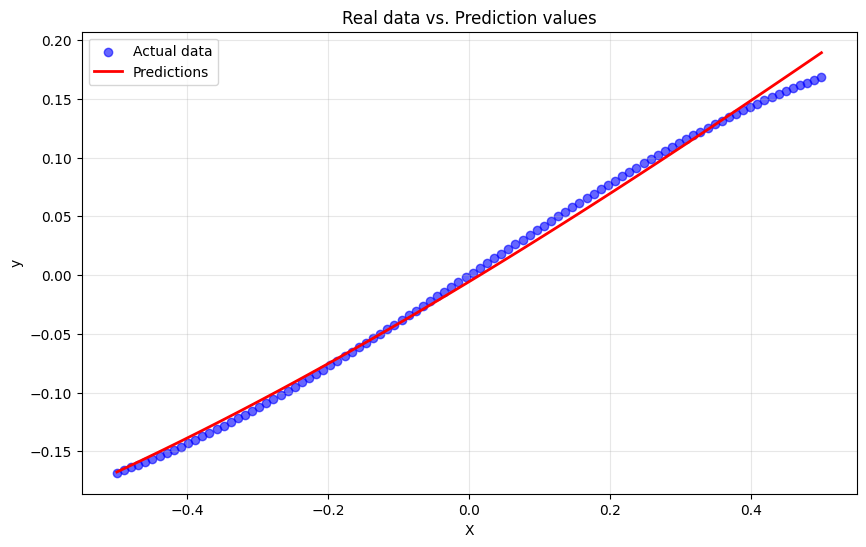

In [21]:
regressor = iqc_regressor_chinese #iqc_regressor_brito#

X, X_final, y_exact = generate_dataset(x_min=-0.5, x_max=0.5, padding_size=0,repeat_input=1,dataset_size=100, func=func4)

best_pos  = training_model(X, X_final, y_exact, max_steps=2000)

best_r2 = evaluate_plot_model(best_pos, X,X_final, y_exact, plot=True)

#6. Experiments

In [ ]:
import pickle
#from google.colab import drive
#drive.mount('/content/drive')
# Salvar arquivo
#dic_results={"TESTE": "TESTE"}


In [25]:
dic_results = pickle.load( open( "dic_results_regressor_att_1111.pkl", "rb" ) )

dic_results_new={}

In [26]:
for key in dic_results.keys():
    if not "g" in key:
        dic_results_new[key] = dic_results[key]

In [28]:
dic_results_new.keys()

dict_keys(['func1_1_False', 'func1_0_1', 'func1_2_1', 'func1_1_2', 'func1_4_0', 'func1_0_3', 'func1_5_2', 'func1_1_6', 'func2_1_False', 'func2_0_1', 'func2_2_1', 'func2_1_2', 'func2_4_0', 'func2_0_3', 'func2_5_2', 'func2_1_6', 'func3_1_False', 'func3_0_1', 'func3_2_1', 'func3_1_2', 'func3_4_0', 'func3_0_3', 'func3_5_2', 'func3_1_6', 'func4_1_False', 'func4_0_1', 'func4_2_1', 'func4_1_2', 'func4_4_0', 'func4_0_3', 'func4_5_2', 'func4_1_6', 'func5_1_False', 'func5_0_1', 'func5_2_1', 'func5_1_2', 'func5_4_0', 'func5_0_3', 'func5_5_2', 'func5_1_6', 'func6_1_False', 'func6_0_1', 'func6_2_1', 'func6_1_2', 'func6_4_0', 'func6_0_3', 'func6_5_2', 'func6_1_6', 'func7_1_False', 'func7_0_1', 'func7_2_1', 'func7_1_2', 'func7_4_0', 'func7_0_3', 'func7_5_2', 'func7_1_6'])

In [30]:
import pickle

SEED=40
np.random.seed(SEED)

dic_results = pickle.load( open( "dic_results_regressor_att_1111.pkl", "rb" ) )

print("ABRIU: ", dic_results)
options_global_best = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}

dicFunctions = {"func1": func1, "func2":func2, "func3":func3, "func4":func4, "func5":func5, "func6":func6, "func7":func7, "g1":lambda x:g(x, k_lim=2),"g2":lambda x:g(x, k_lim=3),"g3":lambda x:g(x, k_lim=4)}

for fun_name in dicFunctions:
  print(fun_name)
  for padding_size, repeat_input in [(1,False), (0,1), (2,1), (1,2), (4,0), (0,3),(5,2), (1,6), (3,0), (0,7), (7,0)]:
    if f"{fun_name}_{padding_size}_{repeat_input}" in dic_results:
      print("passando porque já foi calculado")
      print(f"padding_size: {padding_size}, repeat_input: {repeat_input}")
      continue
    print(f"padding_size: {padding_size}, repeat_input: {repeat_input}")
    if not "g" in fun_name:
      X, X_final, y_exact = generate_dataset(x_min=-1.5, x_max=1.5, padding_size=padding_size,repeat_input=repeat_input,dataset_size=100, func=dicFunctions[fun_name])
    else:
      X, X_final, y_exact = generate_dataset(x_min=-6, x_max=6, padding_size=padding_size,repeat_input=repeat_input,dataset_size=100, func=dicFunctions[fun_name])

    
    best_pos_OPT = training_model(X, X_final, y_exact, max_steps=5000)
    best_cost_OPT = evaluate_plot_model(best_pos_OPT, X,X_final, y_exact,plot=False)

    if best_cost_OPT <= 0.995:
      best_pos_PSO, best_cost_PSO = training_model_PSO(X, X_final, y_exact, max_steps=150,n_particles=60, options_optimizer=options_global_best, verbose=False)
    else:
      best_pos_PSO, best_cost_PSO = None, None
      
    dic_results[f"{fun_name}_{padding_size}_{repeat_input}"] = {"best_pos_PSO": best_pos_PSO, "best_cost_PSO": best_cost_PSO, "best_pos_OPT": best_pos_OPT, "best_cost_OPT": best_cost_OPT}
    print(dic_results)
    pickle.dump(dic_results, open( "dic_results_regressor_att_1111.pkl", "wb" ) )
#

ABRIU:  {'func1_1_False': {'best_pos_PSO': array([-0.11212722,  0.71093146,  0.06663406]), 'best_cost_PSO': np.float64(-0.7108451344038951), 'best_pos_OPT': Array([-0.14343719,  0.71078795,  0.13155338], dtype=float32), 'best_cost_OPT': 0.711}, 'func1_0_1': {'best_pos_PSO': array([-0.09361316,  0.51752454,  0.51886467]), 'best_cost_PSO': np.float64(-0.9400609218362932), 'best_pos_OPT': Array([-0.0937063 ,  0.51839143,  0.5183914 ], dtype=float32), 'best_cost_OPT': 0.94}, 'func1_2_1': {'best_pos_PSO': array([-0.45548883,  0.71112869, -3.2099783 ,  0.7147832 ,  0.7107506 ]), 'best_cost_PSO': np.float64(-0.7108450794131163), 'best_pos_OPT': Array([-0.1408696 ,  0.71078795,  0.11722831,  0.1354145 ,  0.71078795],      dtype=float32), 'best_cost_OPT': 0.711}, 'func1_1_2': {'best_pos_PSO': array([-0.22918169,  0.62949704,  0.51748066,  0.63043255,  0.62983168]), 'best_cost_PSO': np.float64(-0.8704524982159123), 'best_pos_OPT': Array([-0.11072201,  0.62964606,  0.05012669,  0.6296461 ,  0.629